In [48]:
import	pandas					as	pd
import	plotly.graph_objects	as	go
import	plotly.express			as	px
import	numpy					as	np

rng = np.random.default_rng()
p_change = 0.05 # probability of changing states
r = 0.2
noise_var = 0.005
n = 100
dist = 3500
num_paths = 20
decay = 1
means = np.abs(rng.laplace(size = (n, ), scale = 1, loc = 0)) * 2e-7 + 0.0005
means

array([0.00050011, 0.00050019, 0.00050007, 0.00050035, 0.00050049,
       0.00050058, 0.00050004, 0.00050014, 0.00050029, 0.00050139,
       0.00050016, 0.00050029, 0.00050003, 0.00050011, 0.00050023,
       0.0005002 , 0.00050029, 0.00050023, 0.00050016, 0.00050012,
       0.0005    , 0.0005    , 0.00050026, 0.00050005, 0.00050033,
       0.00050076, 0.00050008, 0.00050003, 0.00050054, 0.00050002,
       0.00050024, 0.00050016, 0.0005001 , 0.0005001 , 0.00050036,
       0.00050022, 0.00050002, 0.00050015, 0.00050001, 0.0005007 ,
       0.00050001, 0.00050027, 0.00050002, 0.00050016, 0.0005    ,
       0.00050018, 0.00050007, 0.00050019, 0.00050012, 0.00050006,
       0.00050016, 0.00050014, 0.00050087, 0.00050027, 0.00050002,
       0.00050031, 0.00050021, 0.00050013, 0.00050021, 0.00050037,
       0.0005002 , 0.00050032, 0.00050014, 0.00050018, 0.0005002 ,
       0.00050017, 0.00050017, 0.00050004, 0.00050045, 0.00050012,
       0.00050003, 0.00050014, 0.00050011, 0.0005002 , 0.00050

In [49]:
state = [rng.integers(n) for _ in range(num_paths)]
times = [1.0 for _ in range(num_paths)]
fake_prices = [[rng.random() * 000 + 53] for _ in range(num_paths)]
for _ in range(dist):
	for j in range(num_paths):
		change = (rng.random() > p_change)
		if not change:
			states = [i for i in range(n) if i != state[j]]
			state[j] = rng.choice(states)
			times[j] = 1 / decay
		times[j] *= decay
		# fake_prices.append(np.exp(rng.normal(loc = 0, scale = noise_var)) * (means[state] * (1 - r) + r * fake_prices[-1]))
		fake_prices[j].append(np.exp(rng.standard_t(df = 2) * means[state[j]] * times[j]) * fake_prices[j][-1])
df = pd.DataFrame({f'price_{i}': fake_prices[i] for i in range(num_paths)})
px.line(df, x = df.index, y = [f"price_{i}" for i in range(num_paths)])

In [50]:
returns: pd.DataFrame = pd.DataFrame({f"returns_{i}": np.log(df[f"price_{i}"].shift(-1)/df[f"price_{i}"]).dropna() for i in range(num_paths)})
px.line(returns, x = returns.index, y = [f"returns_{i}" for i in range(num_paths)])

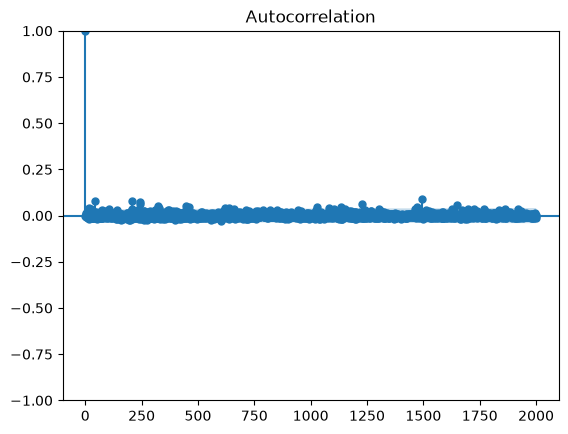

In [51]:
from	statsmodels.graphics.tsaplots	import	plot_acf
acf = plot_acf(np.abs(returns.returns_0), lags = 2000)

In [52]:
sign: pd.Series = (returns.returns_0 > 0).astype('int64')
px.line(x = sign.index, y = sign.values)